# Matrix Reconstruction (Load Trained Model)
Load a saved Linear AE or AE from disk/Drive, recreate the model from the results JSON, analyze latent distributions, and compute reconstruction metrics (MSE, MAE, Frobenius).

In [51]:
from pathlib import Path
import json
import sys
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=4)
warnings.filterwarnings('ignore', message='.*Clustering large matrix.*')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Step 1: Load the desired dataset (test.pt / all.pt)
Load correlation matrices.

In [52]:
DATASET_NAME = 'data_00_20_w724_s10'
RUN = 'AE_3dim_0003'
RESULTS_JSON_PATH = f'models/AE/{RUN}/run_results.json'
DATASET = 'test' #'test' or 'all'


if 'google.colab' in sys.modules:
    print('Environment: Google Colab')
    IS_COLAB = True
else:
    print('Environment: Local PC')
    IS_COLAB = False

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    DRIVE_ROOT = Path('/content/drive/MyDrive')
    base_dir = DRIVE_ROOT / 'dataset_tesi'
else:
    project_root = Path.cwd().resolve().parent
    DRIVE_ROOT = None
    base_dir = project_root / 'data' / 'processed' / 'dataset'

dataset_dir = base_dir / DATASET_NAME

if DATASET == 'all':
    MATRIX_FILE = dataset_dir / 'all.pt'
elif DATASET == 'test':
    MATRIX_FILE = dataset_dir / 'test.pt'

if not MATRIX_FILE.exists():
    raise FileNotFoundError(
        f"File '{MATRIX_FILE.name}' not found in: {dataset_dir.absolute()}"
    )

print(f'Dataset selected: {DATASET_NAME}')
print(f'Test Matrix: {MATRIX_FILE.name}')

Environment: Local PC
Dataset selected: data_00_20_w724_s10
Test Matrix: test.pt


In [53]:
def load_corr_payload(pt_path: Path):
    payload = torch.load(pt_path, map_location='cpu')

    if isinstance(payload, dict):
        corr_tensor = payload.get('corr_tensor', None)
        indices = payload.get('indices', None)
        meta = {k: v for k, v in payload.items() if k != 'corr_tensor'}
    elif isinstance(payload, torch.Tensor):
        corr_tensor = payload
        meta = {}
    else:
        raise TypeError(f'Unsupported .pt format: {type(payload)}')

    if corr_tensor is None:
        raise KeyError('corr_tensor key not found in .pt file')

    if corr_tensor.ndim != 3 or corr_tensor.shape[1] != corr_tensor.shape[2]:
        raise ValueError(f'Invalid shape for corr_tensor: {corr_tensor.shape}')

    return corr_tensor.float(), indices, meta


corr, indices, meta = load_corr_payload(MATRIX_FILE)

print(f'Correlation tensor shape: {corr.shape}')
print(f'Indices: {indices[:10]}')
print(f'Metadata keys: {list(meta.keys())}')

Correlation tensor shape: torch.Size([41, 362, 362])
Indices: [152, 154, 255, 367, 350, 330, 342, 184, 144, 360]
Metadata keys: ['indices', 'split', 'meta']


## Step 2: Prepare Matrices (Full Dataset)
Use full correlation matrices as input. Each matrix is flattened to a vector of size `N x N`.

In [54]:
all_np = corr.numpy().astype(np.float32)

n_matrices, n_assets, _ = all_np.shape
n_features = n_assets * n_assets

x_all = torch.from_numpy(all_np.reshape(n_matrices, n_features))

print(f'Number of matrices: {n_matrices}')
print(f'Matrix shape: ({n_assets}, {n_assets})')
print(f'Flattened input size: {n_features}')

Number of matrices: 41
Matrix shape: (362, 362)
Flattened input size: 131044


## Step 3: Define the Models
Use a Linear Autoencoder (no activations) or a non-linear AutoEncoder (with hidden layers).

In [55]:
class AutoEncoder(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int, hidden_dims=None, dropout_prob: float = 0.02):
        super().__init__()

        # Se hidden_dims e None, creiamo un Linear AE semplice
        if hidden_dims is None:
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, latent_dim),
            )
            self.decoder = nn.Sequential(
                nn.Linear(latent_dim, input_dim),
            )
        else:
            # Caso Deep Autoencoder con Dropout e attivazioni
            dimensions = [input_dim, *hidden_dims, latent_dim]

            # --- ENCODER ---
            encoder_layers = []
            for i in range(len(dimensions) - 1):
                encoder_layers.append(nn.Linear(dimensions[i], dimensions[i + 1]))
                if i < len(dimensions) - 2:
                    encoder_layers.append(nn.ReLU())
                    encoder_layers.append(nn.Dropout(dropout_prob))
            self.encoder = nn.Sequential(*encoder_layers)

            # --- DECODER ---
            decoder_dims = dimensions[::-1]
            decoder_layers = []
            for i in range(len(decoder_dims) - 1):
                decoder_layers.append(nn.Linear(decoder_dims[i], decoder_dims[i + 1]))
                if i < len(decoder_dims) - 2:
                    decoder_layers.append(nn.ReLU())
                    decoder_layers.append(nn.Dropout(dropout_prob))
                else:
                    # Output layer: Tanh e ottima se i dati sono normalizzati tra -1 e 1
                    decoder_layers.append(nn.Tanh())
            self.decoder = nn.Sequential(*decoder_layers)

    def architecture_signature(self):
        return [
            [int(layer.in_features), int(layer.out_features)]
            for layer in self.encoder
            if isinstance(layer, nn.Linear)
        ]

    def forward(self, x: torch.Tensor):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

## Step 4: Load Best Model from Results JSON
Select the results JSON path, load model details, recreate the architecture, and load weights.

In [56]:
def resolve_path(path_str, base_dir=None, results_dir=None):
    if path_str is None:
        return None
    p = Path(path_str)
    if p.is_absolute() and p.exists():
        return p.resolve()

    if results_dir is not None:
        candidate = results_dir / p
        if candidate.exists():
            return candidate.resolve()

    if base_dir is not None:
        candidate = base_dir / p
        if candidate.exists():
            return candidate.resolve()

    normalized = str(path_str).replace('\\', '/')
    if base_dir is not None and 'best_models_tesi' in normalized:
        rel = normalized[normalized.index('best_models_tesi'):]
        candidate = base_dir / rel
        if candidate.exists():
            return candidate.resolve()

    return p


results_path = Path(RESULTS_JSON_PATH)
if not results_path.is_absolute():
    if IS_COLAB:
        if DRIVE_ROOT is None:
            raise ValueError('DRIVE_ROOT is not set for Colab')
        results_path = (DRIVE_ROOT / results_path).resolve()
    else:
        results_path = (project_root / results_path).resolve()

if not results_path.exists():
    raise FileNotFoundError(f'Results JSON not found: {results_path}')

OUTPUT_DIR_NAME = 'analysis_outputs'
analysis_dir = results_path.parent / OUTPUT_DIR_NAME
analysis_dir.mkdir(parents=True, exist_ok=True)

with open(results_path, 'r', encoding='utf-8') as f:
    results = json.load(f)

model_cfg = results.get('model', {})
latent_dim = int(model_cfg.get('latent_dim', 0))
if latent_dim <= 0:
    raise ValueError('Invalid latent_dim in results JSON')

hidden_dims = model_cfg.get('hidden_dims', None)
model_type_raw = str(model_cfg.get('model_type', '')).strip().lower()
if model_type_raw in {'linear', 'linearae', 'linear_ae', 'linear-ae'}:
    model_type = 'linearAE'
elif model_type_raw in {'ae', 'autoencoder', 'auto'}:
    model_type = 'AE'
else:
    model_type = 'AE' if hidden_dims is not None else 'linearAE'

if model_type == 'linearAE':
    hidden_dims = None
else:
    if hidden_dims is None:
        raise ValueError('hidden_dims missing for AE in results JSON')

input_dim = int(model_cfg.get('input_dim', x_all.shape[1]))
if input_dim != x_all.shape[1]:
    raise ValueError(f'Input dim mismatch: json={input_dim}, data={x_all.shape[1]}')

dropout_prob = model_cfg.get('dropout', 0.02)
if dropout_prob is None:
    dropout_prob = 0.0
dropout_prob = float(dropout_prob)

model = AutoEncoder(
    input_dim=input_dim,
    latent_dim=latent_dim,
    hidden_dims=hidden_dims,
    dropout_prob=dropout_prob,
).to(device)

weights_path = results.get('artifacts', {}).get('best_model_path', None)

if weights_path is None:
    run_name = results.get('run', 'run')
    if model_type == 'linearAE':
        weights_path = f'linear_AE_best_{run_name}.pt'
    else:
        weights_path = f'AE_best_{run_name}.pt'

base_dir = DRIVE_ROOT if IS_COLAB else project_root
weights_path = resolve_path(weights_path, base_dir=base_dir, results_dir=results_path.parent)
if weights_path is None or not weights_path.exists():
    raise FileNotFoundError(f'Weights file not found: {weights_path}')

checkpoint = torch.load(weights_path, map_location=device)
state_dict = checkpoint['model_state_dict'] if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint else checkpoint
model.load_state_dict(state_dict)
model.eval()

print(f'Model type: {model_type} | latent_dim={latent_dim} | input_dim={input_dim}')
print(f'Loaded weights: {weights_path}')

Model type: AE | latent_dim=3 | input_dim=131044
Loaded weights: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\AE\AE_3dim_0003\best_model.pt


In [57]:
print(model)

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=131044, out_features=2048, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.02, inplace=False)
    (3): Linear(in_features=2048, out_features=1024, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.02, inplace=False)
    (6): Linear(in_features=1024, out_features=512, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.02, inplace=False)
    (9): Linear(in_features=512, out_features=3, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=3, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.02, inplace=False)
    (3): Linear(in_features=512, out_features=1024, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.02, inplace=False)
    (6): Linear(in_features=1024, out_features=2048, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.02, inplace=False)
    (9): Linear(in_features=2048, out_features=131044, bias=True)
    (10): Tanh()
  )
)


## Step 5: Latent Space Analysis + Reconstruction Errors Analysis
Encode the matrices into the latent space and analyze feature distributions + Analyse MSE, MAE and Frobenius.

In [58]:
def compute_reconstruction(model: nn.Module, x_tensor: torch.Tensor, batch_size: int = 64):
    model.eval()
    loader = DataLoader(TensorDataset(x_tensor), batch_size=batch_size, shuffle=False)
    latents = []
    reconstructions = []

    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            z = model.encoder(xb)
            latents.append(z.cpu().numpy())
            recon = model.decoder(z)
            reconstructions.append(recon.cpu().numpy())

    return np.concatenate(latents, axis=0), np.concatenate(reconstructions, axis=0)

def reconstruction_errors(original: np.ndarray, reconstructed: np.ndarray):
    if original.shape != reconstructed.shape:
        raise ValueError(f'Shape mismatch: {original.shape} vs {reconstructed.shape}')

    diff = original - reconstructed
    mse = np.mean(diff ** 2, axis=(1, 2))
    mae = np.mean(np.abs(diff), axis=(1, 2))
    frob = np.linalg.norm(diff, ord='fro', axis=(1, 2))

    errors_df = pd.DataFrame({'MSE': mse, 'MAE': mae, 'Frobenius': frob})
    summary_df = (
        errors_df.agg(['mean', 'median', 'std', 'min', 'max'])
        .T.reset_index()
        .rename(columns={'index': 'metric'})
    )
    return errors_df, summary_df

Reconstruction error summary (all data):


,metric,mean,median,std,min,max
0,MSE,0.000494,0.000490,0.000231,0.000154,0.001064
1,MAE,0.016088,0.015662,0.004294,0.008775,0.025010
2,Frobenius,7.826985,8.016822,1.903885,4.490292,11.808879


Saved per-matrix errors: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\AE\AE_3dim_0003\analysis_outputs\reconstruction_errors_all_AE_3dim_0003.json
Saved summary stats: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\AE\AE_3dim_0003\analysis_outputs\reconstruction_summary_all_AE_3dim_0003.json
Saved reconstructed matrices: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\AE\AE_3dim_0003\analysis_outputs\all_reconstructed_AE_3dim_0003.pt

Latent distribution summary (all data):


,count,mean,std,min,25%,50%,75%,max
z1,41.0,0.046392,0.896278,-1.712260,-0.543932,0.146261,0.840775,1.249428
z2,41.0,0.894657,0.917418,-0.301499,0.112749,0.666012,1.668525,2.520565
z3,41.0,-0.949210,0.697282,-2.701570,-1.311853,-0.899813,-0.625992,0.274354


Saved latent samples: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\AE\AE_3dim_0003\analysis_outputs\latent_all_AE_3dim_0003.json


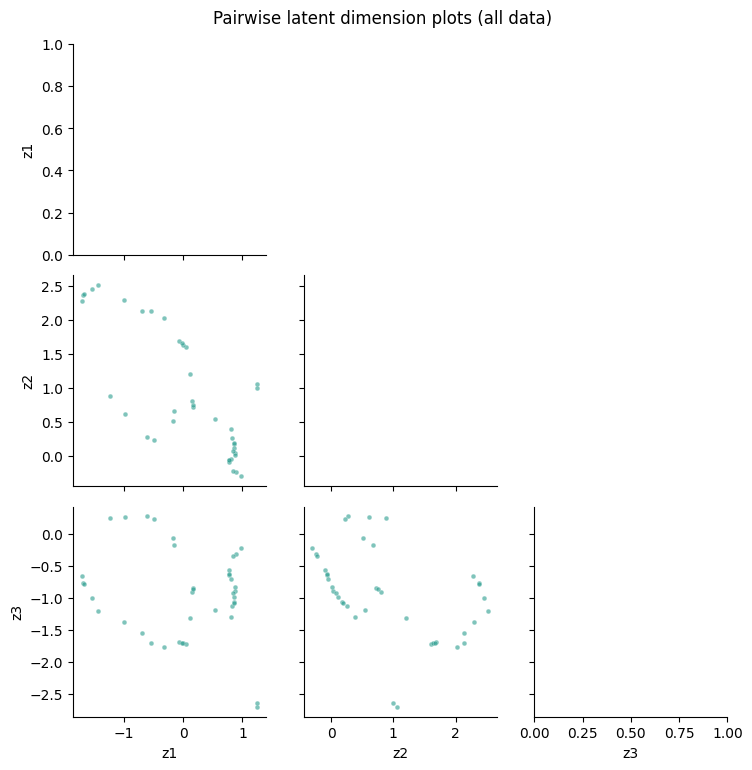

Saved latent pairwise plot: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\AE\AE_3dim_0003\analysis_outputs\latent_pairwise_all_AE_3dim_0003.png


In [59]:
latents_all, recon_all = compute_reconstruction(model, x_all, batch_size=64)
recon_all = recon_all.reshape(all_np.shape)
latent_dim = latents_all.shape[1]
latent_cols = [f'z{i + 1}' for i in range(latent_dim)]
latent_df = pd.DataFrame(latents_all, columns=latent_cols)

errors_df, summary_df = reconstruction_errors(all_np, recon_all)

if len(indices) != len(errors_df):
    raise ValueError(f'Error rows ({len(errors_df)}) do not match indices ({len(indices)})')
errors_df.insert(0, 'matrix_idx', indices)

print('Reconstruction error summary (all data):')
display(summary_df)

errors_json_path = analysis_dir / f'reconstruction_errors_all_{RUN}.json'
summary_json_path = analysis_dir / f'reconstruction_summary_all_{RUN}.json'
errors_df.to_json(errors_json_path, orient='records', indent=2)
summary_df.to_json(summary_json_path, orient='records', indent=2)

print(f'Saved per-matrix errors: {errors_json_path}')
print(f'Saved summary stats: {summary_json_path}')

# Load original payload and create extended version with reconstructed matrices
original_payload = torch.load(MATRIX_FILE, map_location='cpu')
if isinstance(original_payload, dict):
    extended_payload = original_payload.copy()
else:
    # If it's just a tensor, wrap it
    extended_payload = {'corr_tensor': original_payload}

# Add reconstructed matrices as a new key
recon_tensor = torch.from_numpy(recon_all).float()
extended_payload['corr_tensor_reconstructed'] = recon_tensor
extended_payload['tickers'] = meta['meta']['tickers']

# Save to file with the same name but in original location
output_path = analysis_dir / f'all_reconstructed_{RUN}.pt'
torch.save(extended_payload, output_path)
print(f'Saved reconstructed matrices: {output_path}')

print('\nLatent distribution summary (all data):')
display(latent_df.describe().T)

valid_cols = [col for col in latent_cols if latent_df[col].notna().any() and latent_df[col].nunique() > 1]
latent_df = latent_df[valid_cols]

if len(indices) != len(latent_df):
    raise ValueError(f'Latent rows ({len(latent_df)}) do not match indices ({len(indices)})')
latent_df.insert(0, 'matrix_idx', indices)

latent_json_path = analysis_dir / f'latent_all_{RUN}.json'
latent_df.to_json(latent_json_path, orient='records', indent=2)
print(f'Saved latent samples: {latent_json_path}')

if len(valid_cols) < 2:
    print('Not enough valid latent dimensions for pairwise plots.')
else:
    plot_df = latent_df[valid_cols]
    grid = sns.PairGrid(plot_df, corner=True, diag_sharey=False)
    grid.map_lower(sns.scatterplot, s=12, alpha=0.6, color='#2a9d8f')
    grid.figure.suptitle('Pairwise latent dimension plots (all data)', y=1.02)
    pairplot_path = analysis_dir / f'latent_pairwise_all_{RUN}.png'
    grid.savefig(pairplot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved latent pairwise plot: {pairplot_path}')